# Paramount Restaurant Simulation using SimPy

###  Bus 36109 "Advanced Decision Modeling with Python", Don Eisenstein
Don Eisenstein &copy; Copyright 2023, University of Chicago 

---

The Paramount Restaurant is a Boston institution.  Dine-in customers are known to line up for an hour on busy weekends for brunch.   They are investigating the use of Take-Out/Delivery orders. Take-Out orders jump to the front of the line for the cooks, and do not require seating.  Management is worried about the impact Take-out will have on their regular Dine-in customers.

In this initial Paramount Simulation we assume the following.  

- The unit of time is 1 second
- TAKE_OUT_PERCENT is the average proportion of customers that order TAKE_OUT 
- Customers (dine-in and take-out) arrive according to an exponential distribution with mean `MEAN_TIME_BETWEEN_ARRIVALS` time units between them
- Customers then queue for one of `NUM_COOKS`
- Take-out orders also queue for a cook, but jump to the front of the line.
- It takes one cook an exponentially distributed time with mean `MEAN_COOK_TIME_DURATION` time untis to prepare one the food order of one Dine-in customer or Take-out customer
- Dine-In customers then queue for one of `NUM_SEATS`
- The time it takes one Dine-in customer to eat and vacate a seat follows a Uniform(`LOW_EATING_DURATION`,`HIGH_EATING_DURATION`) distributed floating point time units. 
- Run the simulation for `SIM_LENGTH` time units 

Simplifying assumtion:

- We assume communal seating, that is, each customer sits at communal tables with no regard to party/table size. 

Hint:

- To enable Take-Out customers to jump to the head of the line for a Cook, use the `priority` attribute setting for each Entity

## Part 1

Make a simulation run with the following parameters
- SIM_LENGTH = 28800 # 8 hours 
- TAKE_OUT_PERCENTAGE = 0.20
- MEAN_TIME_BETWEEN_ARRIVALS = 52 
- NUM_COOKS = 4
- MEAN_COOK_TIME_DURATION = 290
- NUM_SEATS = 18 
- LOW_EATING_DURATION = 1000
- HIGH_EATING_DURATION = 2000

Output the following statistics:
- Average waiting time for Cooks
- Average waiting time for Cooks for Dine-in customers
- Average waiting time for Cooks for Take-out customers
- Average waiting time for a Seat for Dine-in customers

Make the following plots:
- Plot the Number in Queue for Cooks for Dine-in and Take-out customers combined over time
- Plot the Number in Queue for Seats for Dine-in customers over time

## Part 2

In your notebook, after Part 1 is completed, make the simulation runs to do the following:

- Vary the TAKE_OUT_PERCENTAGE over `[0.0, 0.10, 0.20, 0.30, 0.40, 0.50]`.   For each TAKE_OUT_PERCENTAGE run your simulation 20 times and take the average of the statistic, Average waiting time for Cooks for Dine-in customers.  

-  Plot the TAKE_OUT_PERCENTAGE vs. the average of your 20 runs of the Average waiting time for Cooks for Dine-in customers.  So you will be making 6x20 = 120 runs.  Each of the 6 points you plot will represent the average of 20 runs.   

---

# BEGIN PART 1

In [1]:
import numpy as np
import simpy
from simpy_helpers import Entity, Resource, Source, Stats

In [2]:
SIM_LENGTH = 28800 # 8 hours 
ORDER_TYPE = ['take-out', 'dine-in']
TAKE_OUT_PERCENTAGE = 0.20
MEAN_TIME_BETWEEN_ARRIVALS = 52
NUM_COOKS = 4
MEAN_COOK_TIME_DURATION = 290
NUM_SEATS = 18 
LOW_EATING_DURATION = 1000
HIGH_EATING_DURATION = 2000

**1. Define your Source class**

In [3]:
class GenerateCustomer(Source):

    def interarrival_time(self):
        return np.random.exponential(MEAN_TIME_BETWEEN_ARRIVALS) # seconds

    def build_entity(self):
        attributes = {}
        attributes['order_type'] = np.random.choice(ORDER_TYPE, p=[TAKE_OUT_PERCENTAGE, 1-TAKE_OUT_PERCENTAGE])

        # Assign priority based on customer type
        if attributes['order_type'] == 'take-out':
            attributes['priority'] = 0
        else:
            attributes['priority'] = 1

        return Customer(env, attributes)

**2. Define your Entity class**

In [4]:
class Customer(Entity):

    def process(self):
        # Queue for a cook — take-out jumps the line
        yield self.wait_for_resource(cooks, priority_override=self.attributes['priority'])
        yield self.process_at_resource(cooks)
        self.release_resource(cooks)

        # Take-out customers leave after food is ready
        if self.attributes['order_type'] == 'take-out':
            return

        # Dine-in customers queue for a seat
        yield self.wait_for_resource(seats)
        yield self.process_at_resource(seats)
        self.release_resource(seats)

**3. Define your Resource classes**

In [5]:
class Cooks(Resource):
    def service_time(self, entity):
        return np.random.exponential(MEAN_COOK_TIME_DURATION)

class Seats(Resource):
    def service_time(self, entity):
        return np.random.uniform(LOW_EATING_DURATION, HIGH_EATING_DURATION)

**4. Run your Simulation.**

In [6]:
np.random.seed(1)
env = simpy.Environment()
cooks = Cooks(env, capacity=NUM_COOKS)
seats = Seats(env, capacity=NUM_SEATS)
source = GenerateCustomer(env)

env.process(source.start(debug=False))
env.run(until=SIM_LENGTH)

**5. Output the following statistics:**
- Average waiting time for Cooks
- Average waiting time for Cooks for Dine-in customers
- Average waiting time for Cooks for Take-out customers
- Average waiting time for a Seat for Dine-in customers


In [7]:
print(f'Average waiting time for Cooks is {round(np.mean(Stats.get_waiting_times(cooks)),2)} seconds')
print(f'Average waiting time for Cooks for Dine-in customers is {round(np.mean(Stats.get_waiting_times(cooks, attributes={'order_type':'dine-in'})),2)} seconds')
print(f'Average waiting time for Cooks for Take-out customers is {round(np.mean(Stats.get_waiting_times(cooks, attributes={'order_type':'take-out'})),2)} seconds')
print(f'Average waiting time for Seats is {round(np.mean(Stats.get_waiting_times(seats)),2)} seconds')

Average waiting time for Cooks is 2762.58 seconds
Average waiting time for Cooks for Dine-in customers is 3816.0 seconds
Average waiting time for Cooks for Take-out customers is 109.16 seconds
Average waiting time for Seats is 102.81 seconds


**6. Plot the Number in Queue for Cooks for Dine-in and Take-out customers combined over time.**

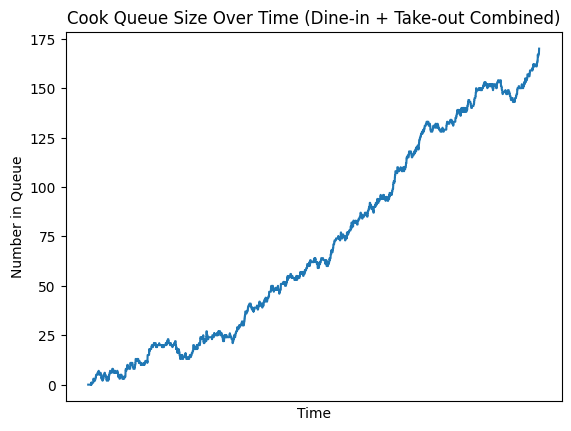

In [8]:
import matplotlib.pyplot as plt

cook_queue = Stats.queue_size_over_time(cooks)
plt.plot(cook_queue)
plt.ylabel('Number in Queue')
plt.xlabel('Time')
plt.title('Cook Queue Size Over Time (Dine-in + Take-out Combined)')
plt.xticks([])
plt.show()

**7. Plot the Number in Queue for Seats for Dine-in customers over time.**

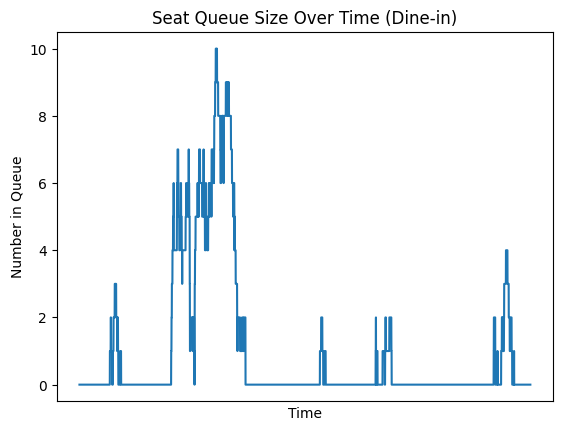

In [9]:
seat_queue = Stats.queue_size_over_time(seats)
plt.plot(seat_queue)
plt.ylabel('Number in Queue')
plt.xlabel('Time')
plt.title('Seat Queue Size Over Time (Dine-in)')
plt.xticks([])
plt.show()

# BEGIN PART 2

**8. Vary the TAKE_OUT_PERCENTAGE over `[0.0, 0.10, 0.20, 0.30, 0.40, 0.50]`.   For each TAKE_OUT_PERCENTAGE run your simulation 20 times and take the average of the statistic, Average waiting time for Cooks for Dine-in customers.** 

**Plot the TAKE_OUT_PERCENTAGE vs. the average of your 20 runs of the Average waiting time for Cooks for Dine-in customers.  So you will be making 6x20 = 120 runs.  Each of the 6 points you plot will represent the average of 20 runs.**

TAKE_OUT_PERCENTAGE=0.0 | Avg dine-in cook wait: 3350.14 seconds
TAKE_OUT_PERCENTAGE=0.1 | Avg dine-in cook wait: 4157.81 seconds
TAKE_OUT_PERCENTAGE=0.2 | Avg dine-in cook wait: 4887.48 seconds
TAKE_OUT_PERCENTAGE=0.3 | Avg dine-in cook wait: 5529.82 seconds
TAKE_OUT_PERCENTAGE=0.4 | Avg dine-in cook wait: 5845.06 seconds
TAKE_OUT_PERCENTAGE=0.5 | Avg dine-in cook wait: 7328.04 seconds


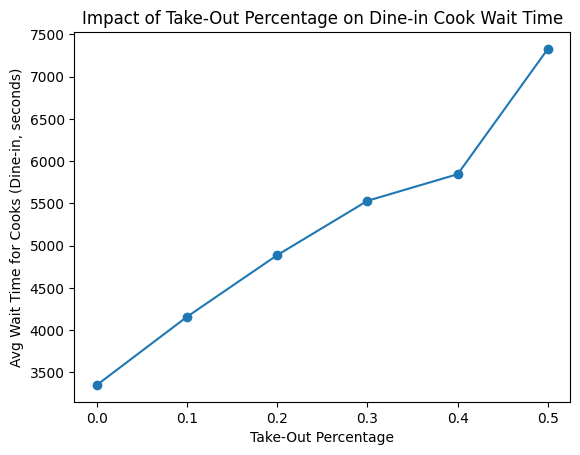

In [10]:
TAKE_OUT_PERCENTAGES = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
NUM_RUNS = 20

plot_points = []
avg_dine_in_wait_times = []

for TAKE_OUT_PERCENTAGE in TAKE_OUT_PERCENTAGES:
    run_averages = []
    
    for run in range(NUM_RUNS):
        env = simpy.Environment()
        cooks = Cooks(env, capacity=NUM_COOKS)
        seats = Seats(env, capacity=NUM_SEATS)
        source = GenerateCustomer(env)
        
        env.process(source.start(debug=False))
        env.run(until=SIM_LENGTH)
        
        dine_in_cook_waits = Stats.get_waiting_times(cooks, attributes={'order_type': 'dine-in'})
        run_averages.append(np.mean(dine_in_cook_waits))
    
    avg_dine_in_wait_times.append(np.mean(run_averages))
    plot_points.append(TAKE_OUT_PERCENTAGE)
    print(f'TAKE_OUT_PERCENTAGE={TAKE_OUT_PERCENTAGE} | Avg dine-in cook wait: {round(np.mean(run_averages), 2)} seconds')

plt.plot(plot_points, avg_dine_in_wait_times, marker='o')
plt.xlabel('Take-Out Percentage')
plt.ylabel('Avg Wait Time for Cooks (Dine-in, seconds)')
plt.title('Impact of Take-Out Percentage on Dine-in Cook Wait Time')
plt.xticks(plot_points)
plt.show()